In [1]:
# retrieving functions from lindbladian.ipnyb
%run '/home/jovyan/NSERC 2026/[1] [lindbladian helper code] [may 19]/lindbladian.ipynb'

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
[NbConvertApp] WARNING | pattern 'lindbladian.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_c

In [2]:
# using 'Science' style plots
plt.style.use(['science', 'high-vis'])

J = sp.Symbol("J", real=True, positive=True)
epsilon  = sp.Symbol("epsilon", real=True, positive=True)
gamma = sp.Symbol("Gamma", real=True, positive=True)

In [3]:
def find_liousvillian_gap(matrix, atol=1e-17):
    # if converting to numpy just in case:
    matrix = np.array(matrix).astype(complex)
    
    # finding evals
    evals = scipy.linalg.eigvals(matrix)

    # uses a mask to eliminate the 0 eigenvalue (may have to adjust tolerance),
    # then finds the min of the magnitudes of the real parts of the non-zero evals
    return np.min(np.abs(np.real(evals)[~np.isclose(np.real(evals),np.zeros(np.shape(matrix)[0]), atol=atol)]))

In [30]:
def linear_fit(fig, ax, x, y):
    # linear fit of the form: y=mx+b
    m, b, r_value, p_value, std_err = scipy.stats.linregress(x, y)
    ax.plot(x,m*x+b, color="gray", linestyle="--", alpha=0.5, label="linear fit")
    ax.annotate(fr"$y={np.real(m):.4f}x{"+" if np.real(b)>0 else "-"}{np.abs(b):.4f}$"+ "\n" + fr"$R^2 = {np.real(r_value)**2:.4f}$",
                         (0.1,0.8),
                         xycoords="axes fraction",
                         fontsize="14",
                         ha="left"
                        )
    return m, b, r_value**2, std_err

### The following code is copied from [Roi Nevo's GitHub](https://github.com/roinevo/disordered-spin-network-relaxation-data/blob/7e5d388ad6f8d53e1e5b15836f6a95b140d892e7/plotting_notebooks/Fig_model_dynamics_examples.ipynb) and reproduces Configuration A (as seen in Fig. 4 of NV draft)

In [4]:
%run bath_functions.ipynb

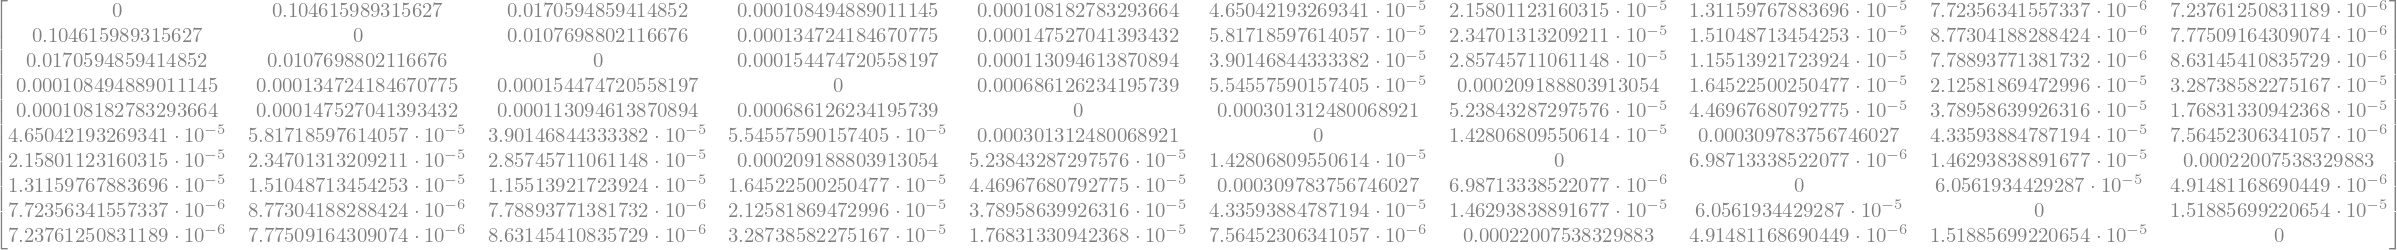

In [7]:
a = 5
key = random.PRNGKey(a)
Jmax = 1.0
alpha = 3.0
Gamma = 0.1
d_min = 0.5

R = 16/ d_min
sigma  = 0.01
N= int(round(sigma * R**2))
N


#print(f'a={a}')

key = random.PRNGKey(a)


positions = random_bath_positions(key, radius=R, num_particles=N, dim=2)
rho0 = jnp.zeros((N, N), dtype=jnp.complex128).at[0, 0].set(1.0)  # ← Add dtype
tlist =  jnp.geomspace(1, 10**9,1000)
H, sort_order = Hampl_geometric(key, positions, Jmax, alpha, double_precision=True)
L = lindbladmatpl(H, Gamma, double_precision=True)
rhos = evolve_rho_over_time(L, rho0, tlist, double_precision=True)

'''plot_rho_geometric_frame(rhos[-int(0.1*len(tlist))], positions[sort_order], 
                        coherence_percentile=-1.0000, 
                        title="", 
                        radius=R)'''

H_sympy = sp.Matrix(H)
H_sympy

### This is my code now...

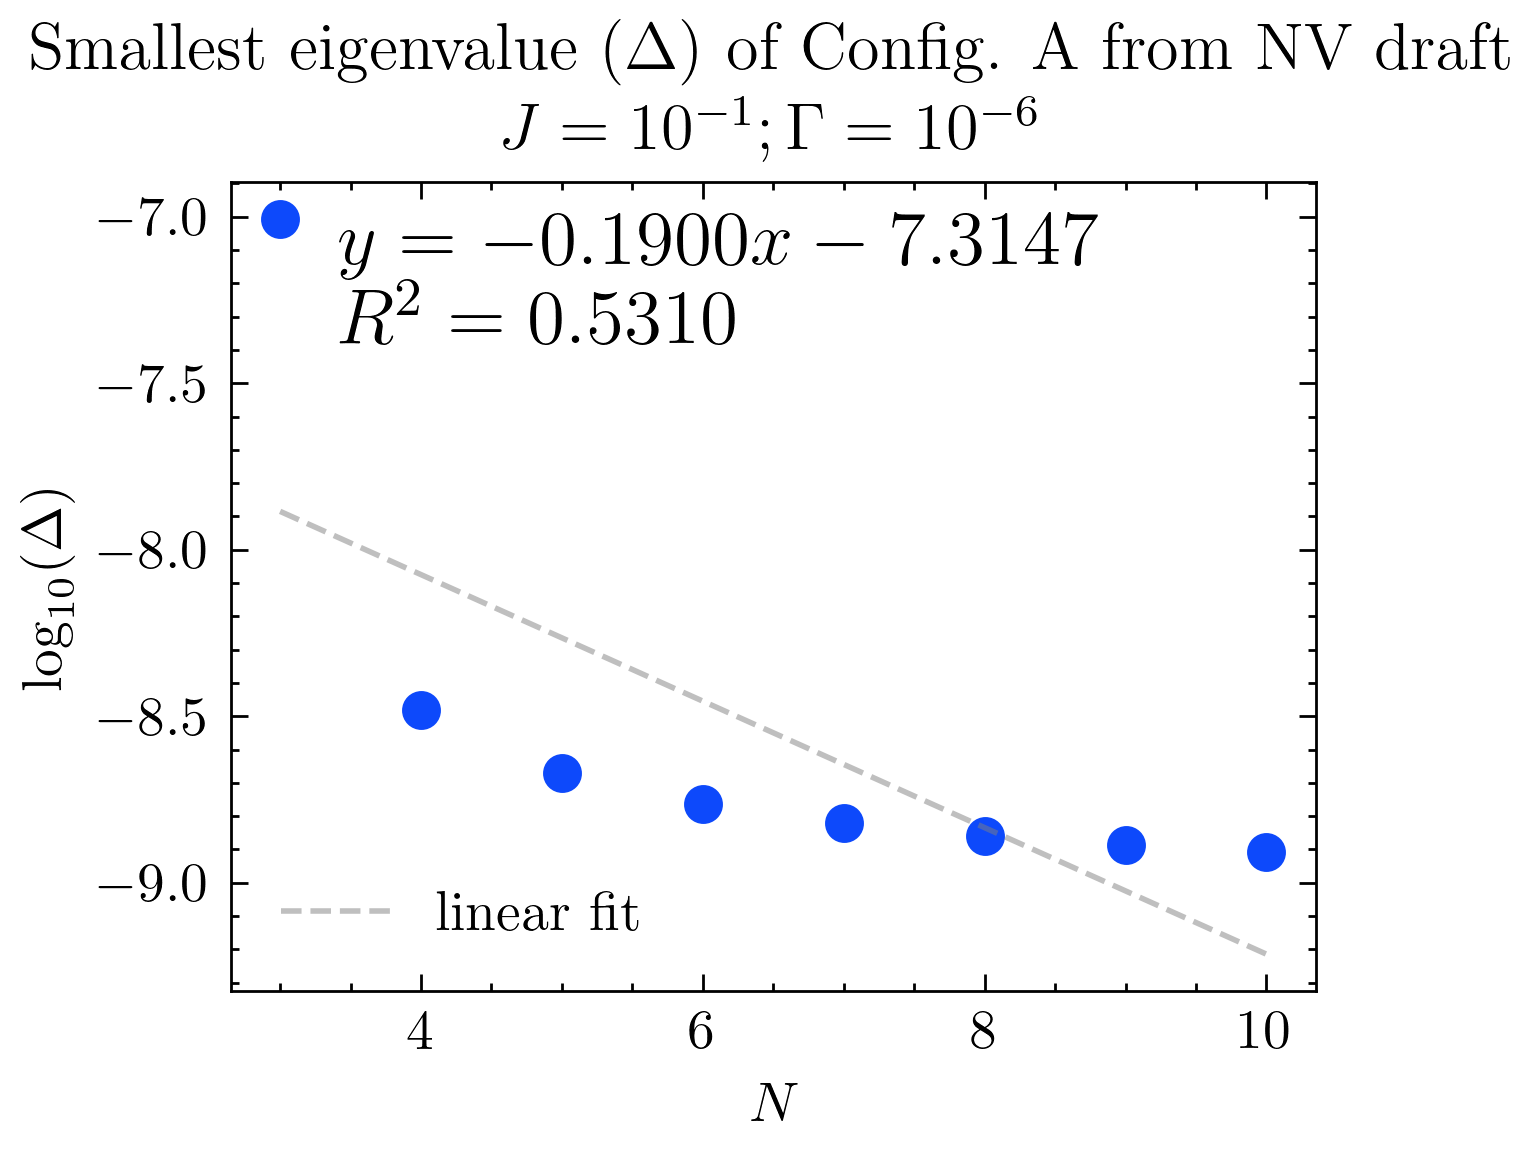

In [54]:

gaps = []
J_val = 0.1
epsilon_val = 1
gamma_val = 1e-6
N_start = 3
N_stop = 10


for N in range(N_start,N_stop+1):
    #display(H_sympy[:N, :N])

    L_operators = [sp.Matrix(N,N, lambda i,j: 1 if i==k and j==k else 0) for k in range(N)]
    L, rho = lindbladian(output=False, H=H_sympy[:N, :N], L_operators=L_operators, damping_rates=[gamma_val for i in range(N)])

    #display(L)
    gaps.append(find_liousvillian_gap(L))




fig, ax = plt.subplots()

# PLOTTING
x = np.arange(N_start,N_stop+1)
y = np.log10(np.asarray(gaps))
ax.scatter(x, y)
linear_fit(fig, ax, x, y)
ax.set_xlabel(r"$N$")
ax.set_ylabel(r"$ \textrm{log}_{10} ( \Delta )$")
ax.set_title(rf"Smallest eigenvalue ($\Delta$) of Config. A from NV draft" + "\n" + rf"$J=10^{{{int(np.log10(J_val))}}}; \Gamma=10^{{{int(np.log10(gamma_val))}}}$")
ax.legend()

fig.savefig(f"J={J_val}; gamma={gamma_val}; N_start={N_start}; N_stop={N_stop}.pdf")





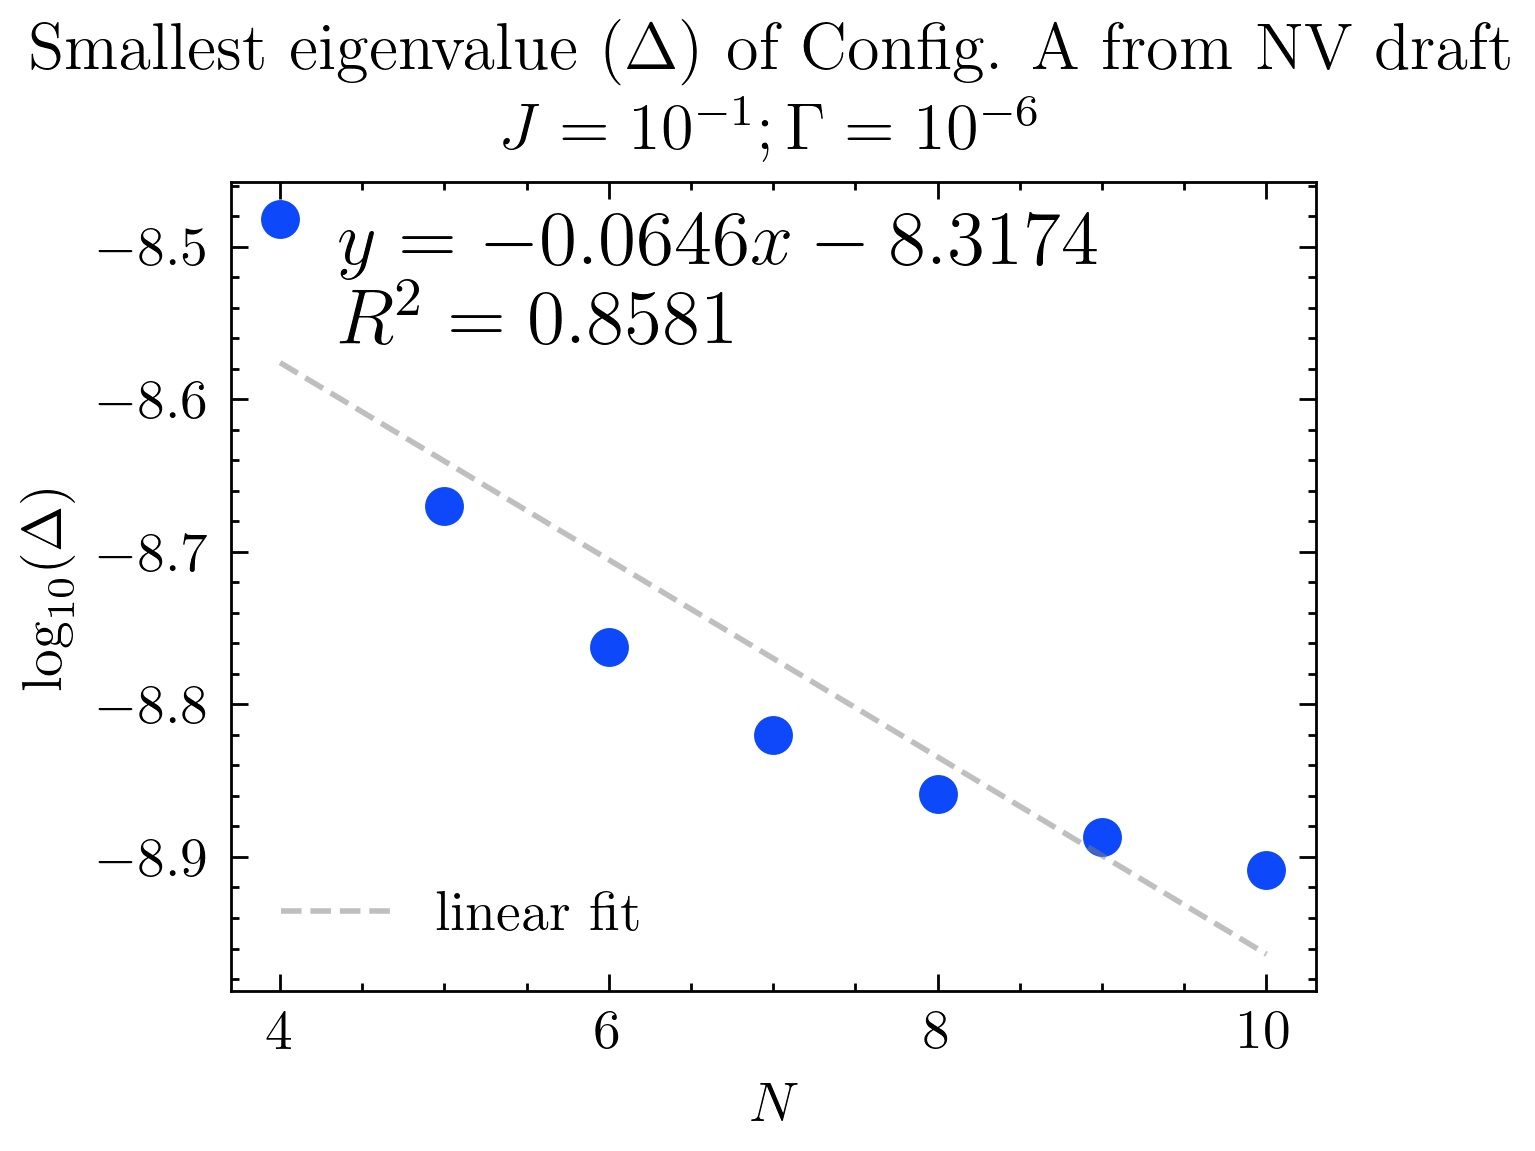

In [56]:

gaps = []
J_val = 0.1
epsilon_val = 1
gamma_val = 1e-6
N_start = 4
N_stop = 10


for N in range(N_start,N_stop+1):
    #display(H_sympy[:N, :N])

    L_operators = [sp.Matrix(N,N, lambda i,j: 1 if i==k and j==k else 0) for k in range(N)]
    L, rho = lindbladian(output=False, H=H_sympy[:N, :N], L_operators=L_operators, damping_rates=[gamma_val for i in range(N)])

    #display(L)
    gaps.append(find_liousvillian_gap(L))




fig, ax = plt.subplots()

# PLOTTING
x = np.arange(N_start,N_stop+1)
y = np.log10(np.asarray(gaps))
ax.scatter(x, y)
linear_fit(fig, ax, x, y)
ax.set_xlabel(r"$N$")
ax.set_ylabel(r"$ \textrm{log}_{10} ( \Delta )$")
ax.set_title(rf"Smallest eigenvalue ($\Delta$) of Config. A from NV draft" + "\n" + rf"$J=10^{{{int(np.log10(J_val))}}}; \Gamma=10^{{{int(np.log10(gamma_val))}}}$")
ax.legend()

fig.savefig(f"J={J_val}; gamma={gamma_val}; N_start={N_start}; N_stop={N_stop}.pdf")



